# NB07: Synthesis — Publication Figures & Summary

**Goal**: Combine results from NB02-NB06 into publication-quality figures
and an integrated summary table.

**Compute**: Local (5-10 min)

**Outputs**:
- 4 publication figures
- `data/integrated_summary.csv` — one row per species, all metrics
- Key statistics for abstract

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path(os.getcwd()).parent
DATA_DIR = PROJECT_DIR / 'data'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
})

## 1. Load All Results

In [2]:
variation = pd.read_csv(DATA_DIR / 'amr_variation_by_species.csv')
prevalence = pd.read_csv(DATA_DIR / 'amr_prevalence_by_gene.csv')
islands = pd.read_csv(DATA_DIR / 'resistance_islands.csv') if (DATA_DIR / 'resistance_islands.csv').exists() else pd.DataFrame()
phi_summary = pd.read_csv(DATA_DIR / 'phi_summary.csv') if (DATA_DIR / 'phi_summary.csv').exists() else pd.DataFrame()
mantel = pd.read_csv(DATA_DIR / 'mantel_results.csv') if (DATA_DIR / 'mantel_results.csv').exists() else pd.DataFrame()
ecotypes = pd.read_csv(DATA_DIR / 'ecotype_summary.csv') if (DATA_DIR / 'ecotype_summary.csv').exists() else pd.DataFrame()
temporal = pd.read_csv(DATA_DIR / 'temporal_amr_trends.csv') if (DATA_DIR / 'temporal_amr_trends.csv').exists() else pd.DataFrame()
bridge = pd.read_csv(DATA_DIR / 'bacdive_amr_bridge.csv') if (DATA_DIR / 'bacdive_amr_bridge.csv').exists() else pd.DataFrame()

print("Loaded datasets:")
for name, df in [('variation', variation), ('prevalence', prevalence),
                  ('islands', islands), ('phi_summary', phi_summary),
                  ('mantel', mantel), ('ecotypes', ecotypes),
                  ('temporal', temporal), ('bridge', bridge)]:
    print(f"  {name}: {len(df)} rows")

Loaded datasets:
  variation: 1305 rows
  prevalence: 37444 rows
  islands: 1517 rows
  phi_summary: 1305 rows
  mantel: 1261 rows
  ecotypes: 974 rows
  temporal: 513 rows
  bridge: 1307 rows


## 2. Integrated Summary Table

In [3]:
# Build integrated table: one row per species
summary = variation[['gtdb_species_clade_id', 'n_genomes', 'n_amr',
                      'n_fixed', 'n_variable', 'n_rare',
                      'variability_index', 'mean_jaccard', 'mean_entropy',
                      'mean_amr_per_genome', 'phylum', 'openness']].copy()

# Add phi/islands
if len(phi_summary) > 0:
    summary = summary.merge(
        phi_summary[['gtdb_species_clade_id', 'n_variable_genes', 'mean_phi',
                      'frac_strong_phi', 'n_islands']],
        on='gtdb_species_clade_id', how='left'
    )

# Add Mantel
if len(mantel) > 0:
    summary = summary.merge(
        mantel[['gtdb_species_clade_id', 'mantel_r_all', 'mantel_fdr_all',
                'mantel_r_core', 'mantel_r_noncore']],
        on='gtdb_species_clade_id', how='left'
    )

# Add ecotypes
if len(ecotypes) > 0:
    summary = summary.merge(
        ecotypes[['gtdb_species_clade_id', 'n_clusters', 'silhouette']],
        on='gtdb_species_clade_id', how='left'
    )

# Add temporal
if len(temporal) > 0:
    summary = summary.merge(
        temporal[['gtdb_species_clade_id', 'slope', 'fdr']].rename(
            columns={'slope': 'temporal_slope', 'fdr': 'temporal_fdr'}),
        on='gtdb_species_clade_id', how='left'
    )

summary.to_csv(DATA_DIR / 'integrated_summary.csv', index=False)
print(f"Integrated summary: {len(summary)} species x {summary.shape[1]} columns")

Integrated summary: 1305 species x 24 columns


## 3. Figure 1: AMR Variation Landscape

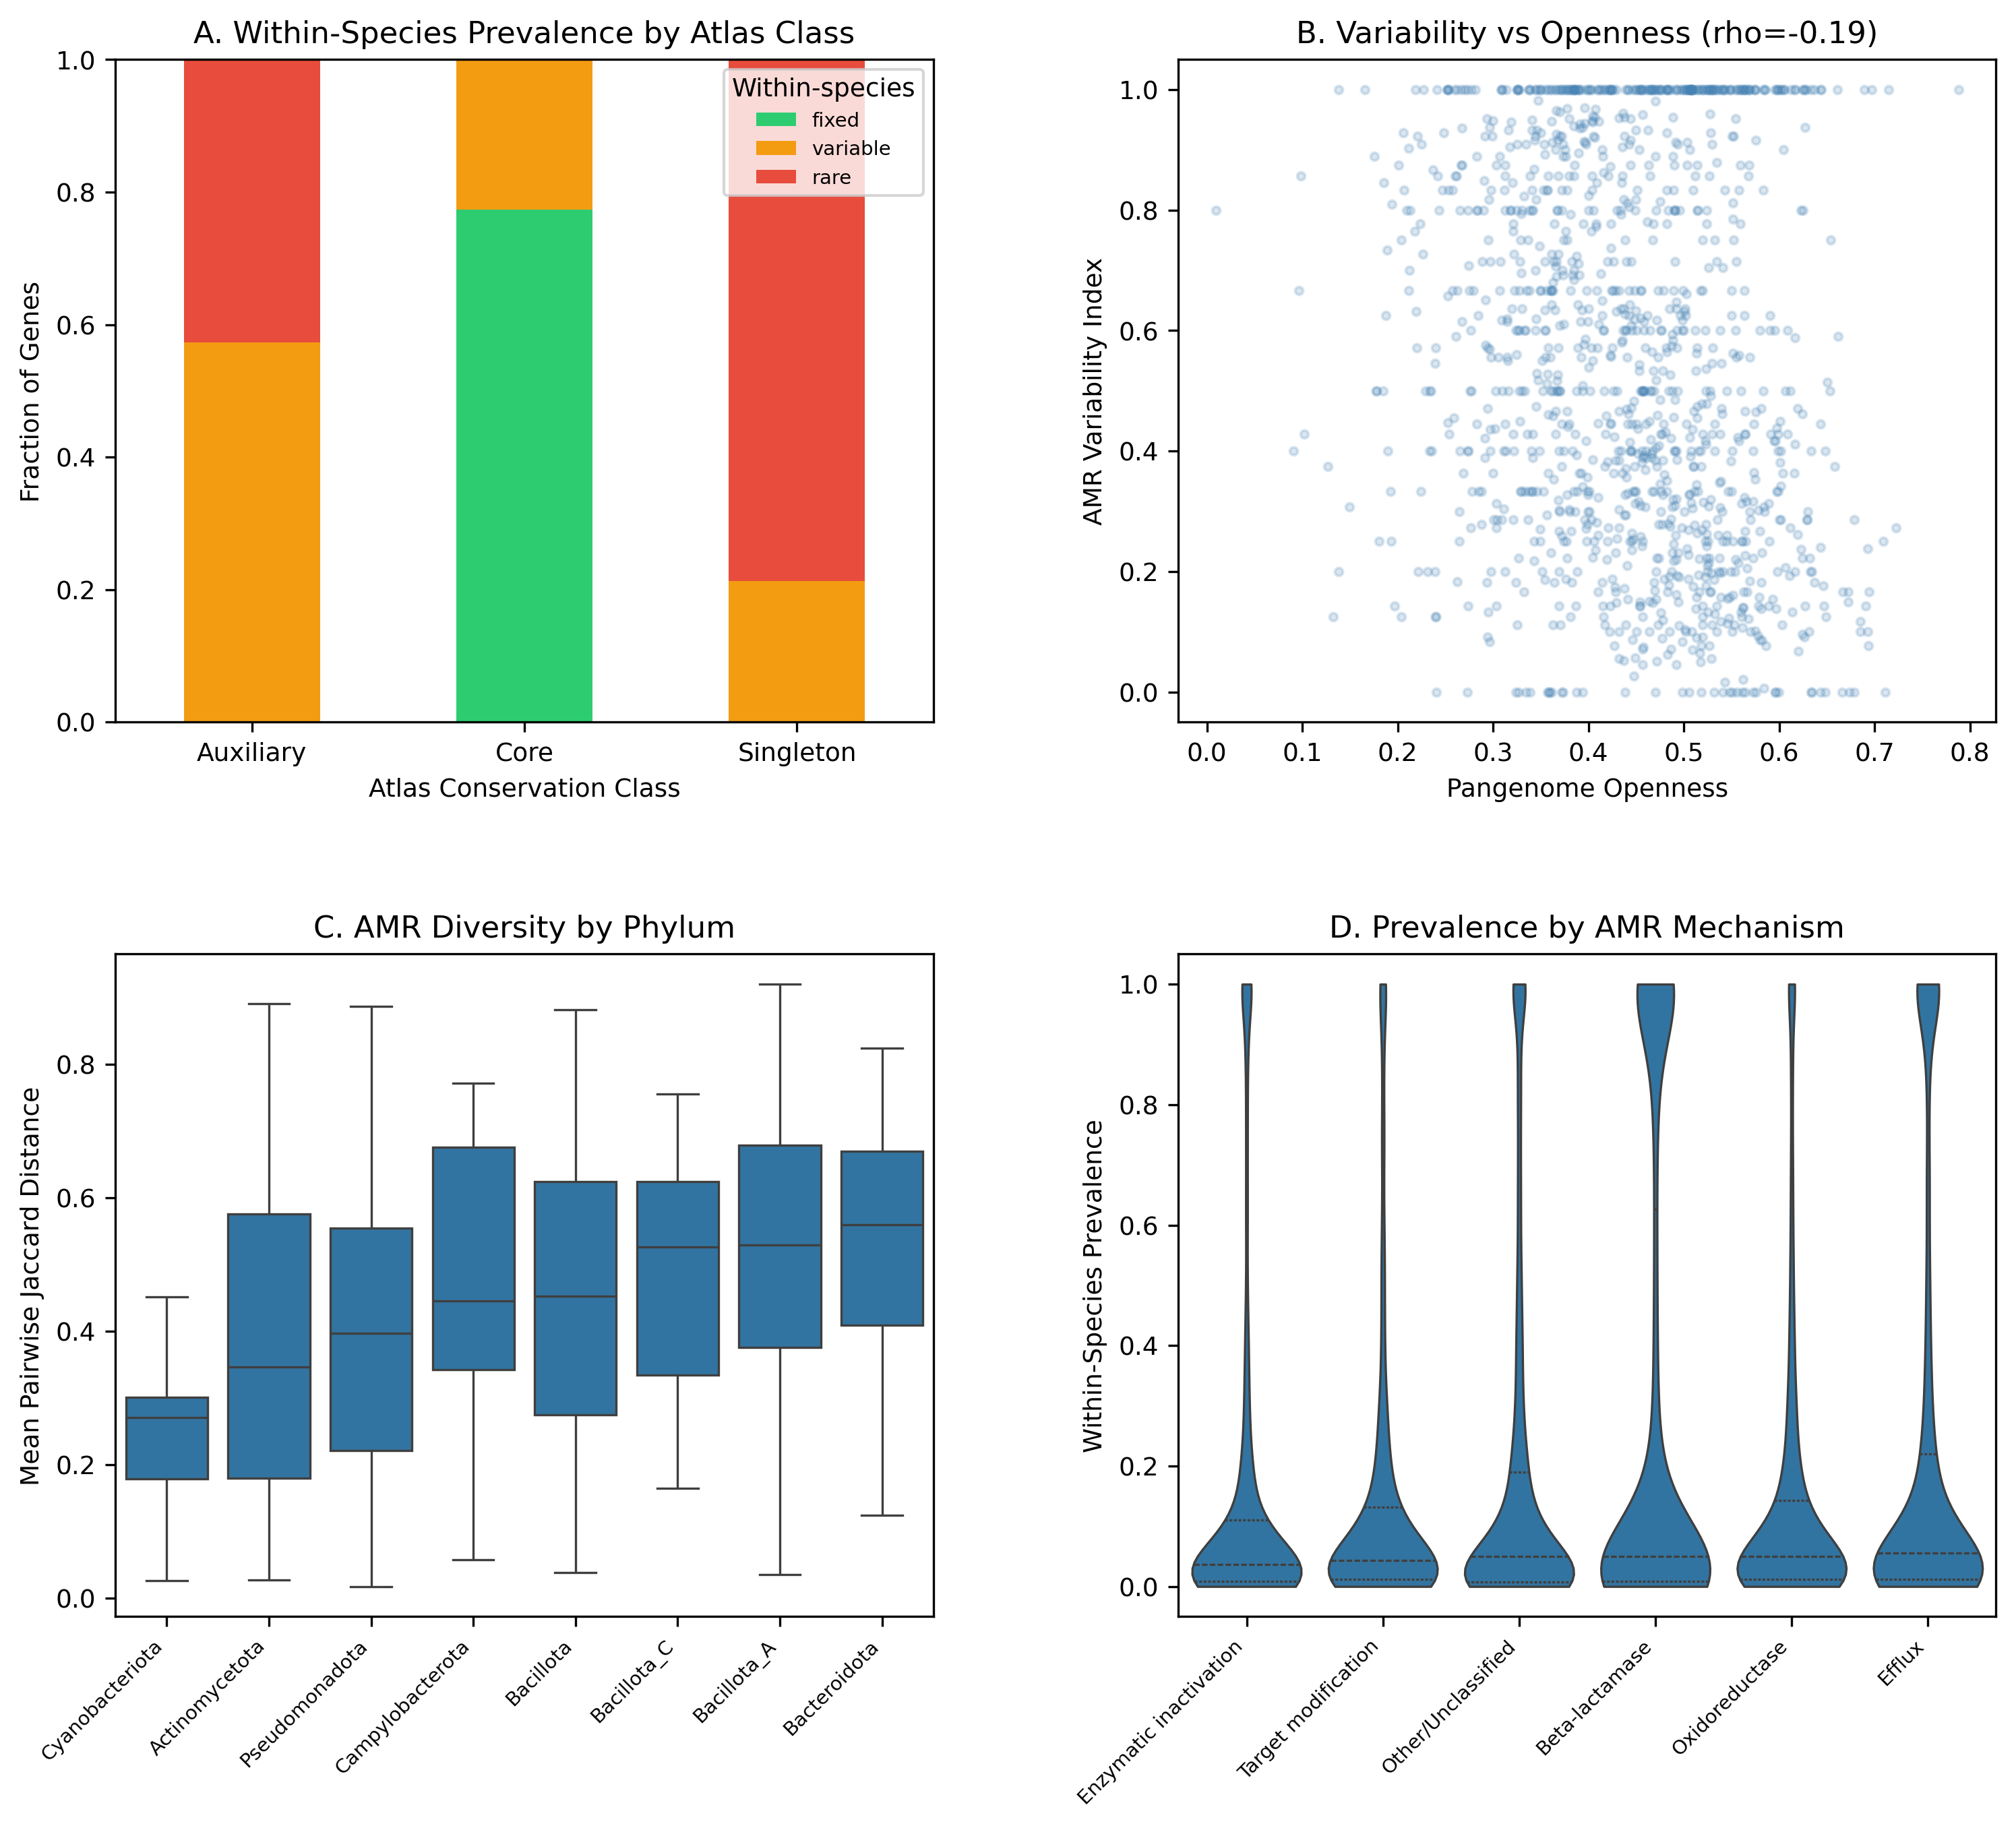

In [4]:
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# 1A: Prevalence class stacked bar by conservation class
ax = fig.add_subplot(gs[0, 0])
cross = pd.crosstab(prevalence['conservation_class'], prevalence['prevalence_class'],
                     normalize='index')
if 'fixed' in cross.columns:
    cross = cross[['fixed', 'variable', 'rare']]
cross.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_xlabel('Atlas Conservation Class')
ax.set_ylabel('Fraction of Genes')
ax.set_title('A. Within-Species Prevalence by Atlas Class')
ax.legend(title='Within-species', fontsize=7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 1B: Variability index vs openness
ax = fig.add_subplot(gs[0, 1])
ax.scatter(summary['openness'], summary['variability_index'],
           alpha=0.2, s=8, c='steelblue')
r, p = stats.spearmanr(summary['openness'].dropna(),
                        summary.loc[summary['openness'].notna(), 'variability_index'])
ax.set_xlabel('Pangenome Openness')
ax.set_ylabel('AMR Variability Index')
ax.set_title(f'B. Variability vs Openness (rho={r:.2f})')

# 1C: Mean Jaccard diversity by phylum
ax = fig.add_subplot(gs[1, 0])
top_phyla = summary['phylum'].value_counts().head(8).index
phylum_data = summary[summary['phylum'].isin(top_phyla)]
order = phylum_data.groupby('phylum')['mean_jaccard'].median().sort_values().index
sns.boxplot(data=phylum_data, x='phylum', y='mean_jaccard', order=order, ax=ax,
            fliersize=2, linewidth=0.8)
ax.set_xticklabels([p.replace('p__', '') for p in order], rotation=45, ha='right', fontsize=7)
ax.set_xlabel('')
ax.set_ylabel('Mean Pairwise Jaccard Distance')
ax.set_title('C. AMR Diversity by Phylum')

# 1D: Prevalence distribution by mechanism
ax = fig.add_subplot(gs[1, 1])
top_mechs = prevalence['mechanism'].value_counts().head(6).index
mech_data = prevalence[prevalence['mechanism'].isin(top_mechs)]
mech_order = mech_data.groupby('mechanism')['prevalence'].median().sort_values().index
sns.violinplot(data=mech_data, x='mechanism', y='prevalence', order=mech_order,
               ax=ax, cut=0, inner='quartile', linewidth=0.8, scale='width')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_xlabel('')
ax.set_ylabel('Within-Species Prevalence')
ax.set_title('D. Prevalence by AMR Mechanism')

plt.savefig(FIG_DIR / 'fig1_variation_landscape.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig1_variation_landscape.pdf', bbox_inches='tight')
plt.show()

## 4. Figure 2: Resistance Islands

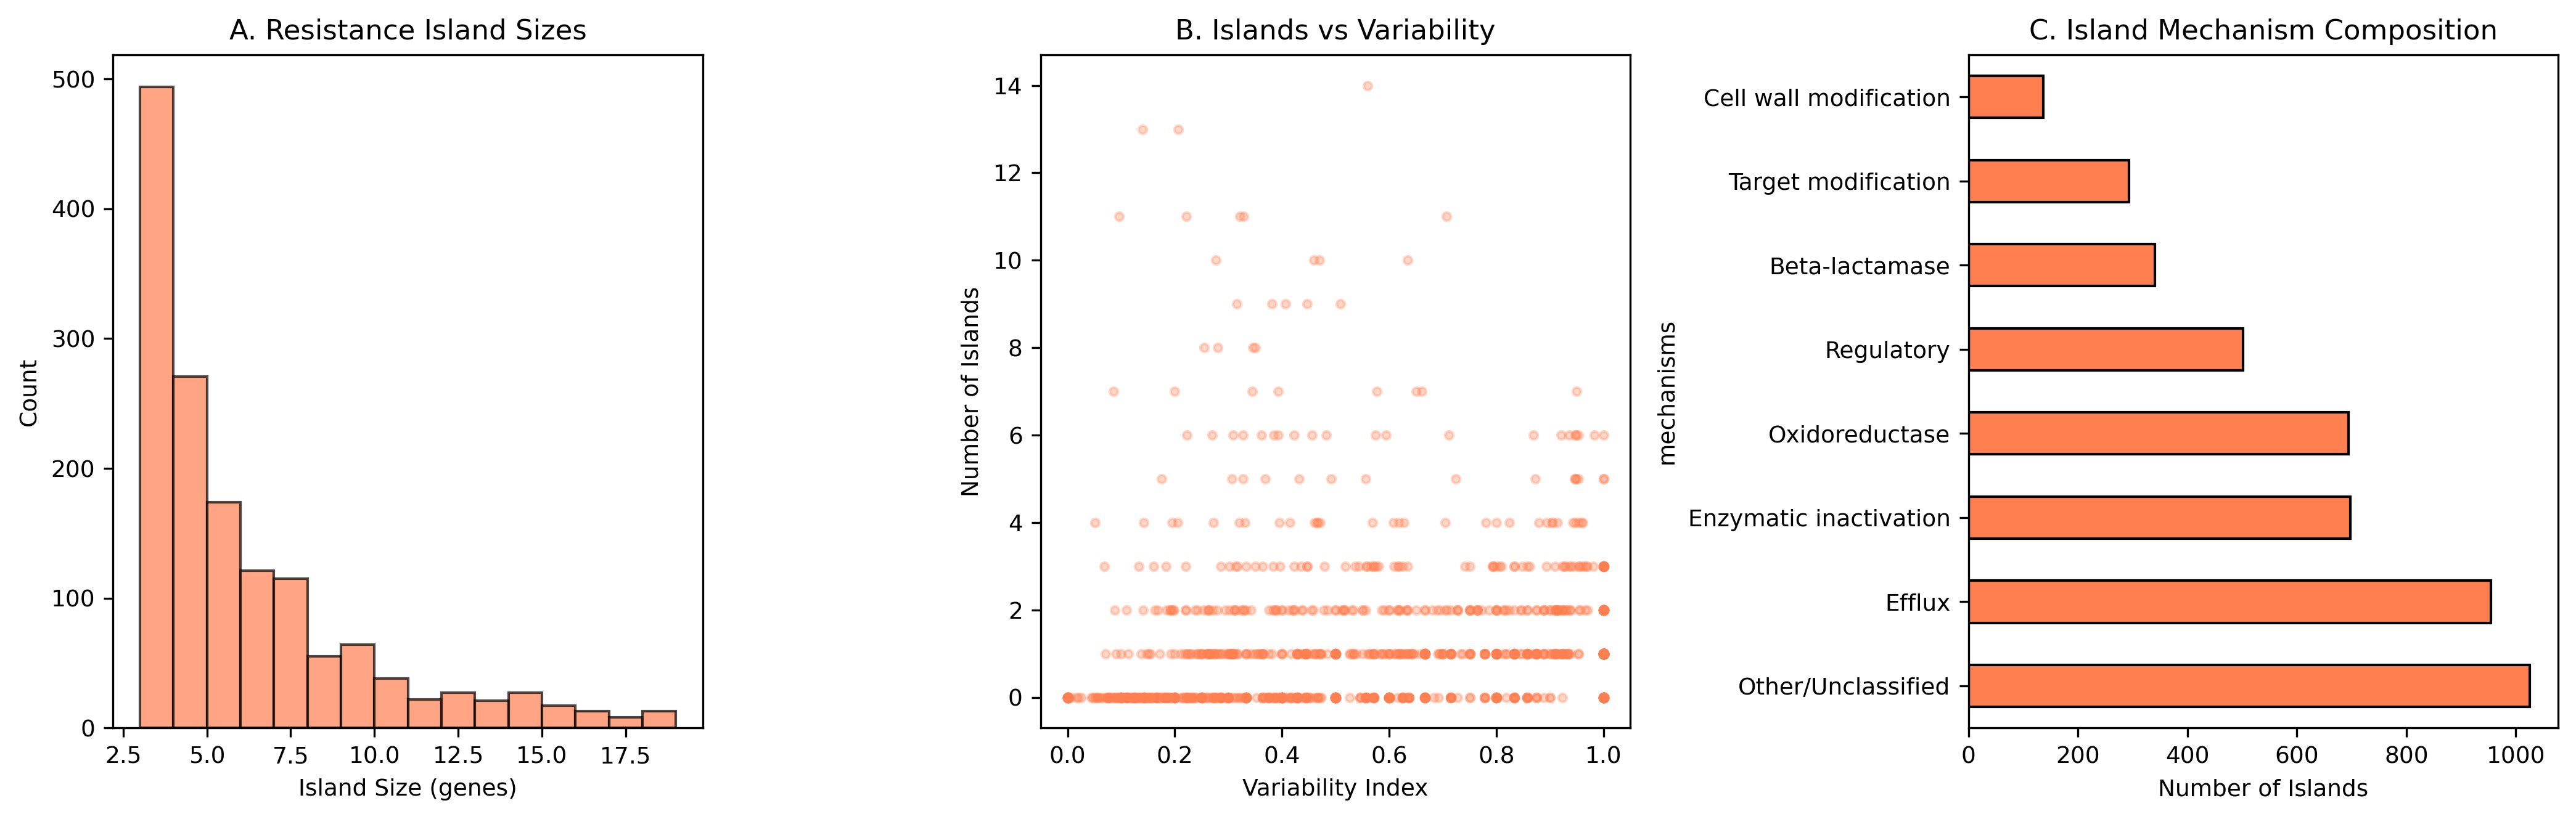

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 2A: Island size distribution
ax = axes[0]
if len(islands) > 0:
    ax.hist(islands['size'], bins=range(3, min(islands['size'].max()+2, 20)),
            edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Island Size (genes)')
ax.set_ylabel('Count')
ax.set_title('A. Resistance Island Sizes')

# 2B: Islands per species vs variability
ax = axes[1]
if 'n_islands' in summary.columns:
    has_islands = summary.dropna(subset=['n_islands'])
    ax.scatter(has_islands['variability_index'], has_islands['n_islands'],
               alpha=0.3, s=10, c='coral')
    ax.set_xlabel('Variability Index')
    ax.set_ylabel('Number of Islands')
    ax.set_title('B. Islands vs Variability')

# 2C: Mechanism composition of islands
ax = axes[2]
if len(islands) > 0:
    mech_counts = islands['mechanisms'].str.split('|').explode().value_counts().head(8)
    mech_counts.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Number of Islands')
    ax.set_title('C. Island Mechanism Composition')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_resistance_islands.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig2_resistance_islands.pdf', bbox_inches='tight')
plt.show()

## 5. Figure 3: Phylogenetic Signal

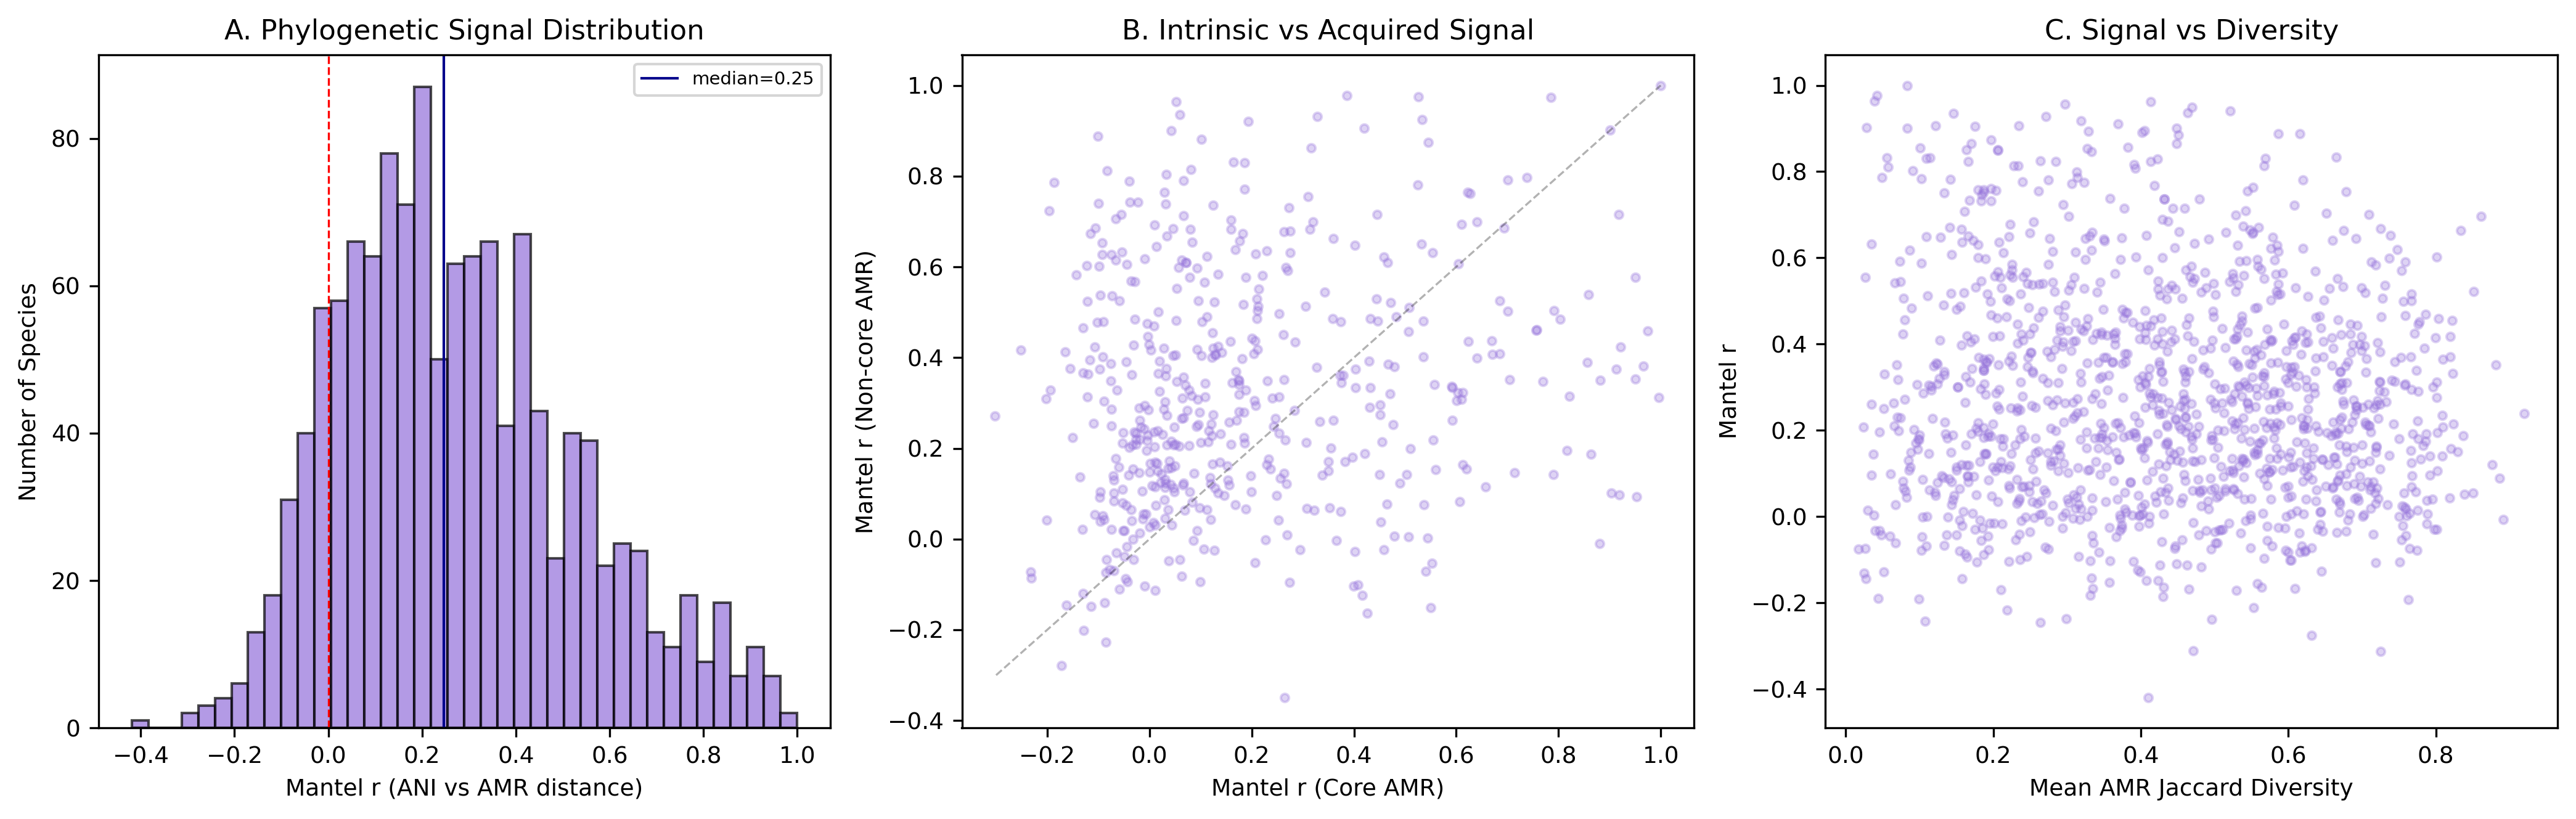

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 3A: Mantel r distribution
ax = axes[0]
if len(mantel) > 0:
    ax.hist(mantel['mantel_r_all'].dropna(), bins=40, edgecolor='black',
            alpha=0.7, color='mediumpurple')
    ax.axvline(0, color='red', ls='--', linewidth=0.8)
    med = mantel['mantel_r_all'].median()
    ax.axvline(med, color='darkblue', ls='-', linewidth=1,
               label=f'median={med:.2f}')
    ax.legend(fontsize=7)
ax.set_xlabel('Mantel r (ANI vs AMR distance)')
ax.set_ylabel('Number of Species')
ax.set_title('A. Phylogenetic Signal Distribution')

# 3B: Core vs non-core
ax = axes[1]
if len(mantel) > 0 and 'mantel_r_core' in mantel.columns:
    both = mantel.dropna(subset=['mantel_r_core', 'mantel_r_noncore'])
    if len(both) > 0:
        ax.scatter(both['mantel_r_core'], both['mantel_r_noncore'],
                   alpha=0.3, s=10, c='mediumpurple')
        lim = max(both[['mantel_r_core', 'mantel_r_noncore']].max().max(), 0.5)
        ax.plot([-0.3, lim], [-0.3, lim], 'k--', alpha=0.3, linewidth=0.8)
ax.set_xlabel('Mantel r (Core AMR)')
ax.set_ylabel('Mantel r (Non-core AMR)')
ax.set_title('B. Intrinsic vs Acquired Signal')

# 3C: Phylogenetic signal vs genome diversity
ax = axes[2]
if len(mantel) > 0:
    merged = summary.merge(mantel[['gtdb_species_clade_id', 'mantel_r_all']],
                           on='gtdb_species_clade_id', how='inner', suffixes=('', '_m'))
    ax.scatter(merged['mean_jaccard'], merged['mantel_r_all'],
               alpha=0.3, s=10, c='mediumpurple')
    ax.set_xlabel('Mean AMR Jaccard Diversity')
    ax.set_ylabel('Mantel r')
    ax.set_title('C. Signal vs Diversity')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_phylogenetic_signal.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3_phylogenetic_signal.pdf', bbox_inches='tight')
plt.show()

## 6. Figure 4: AMR Ecotypes

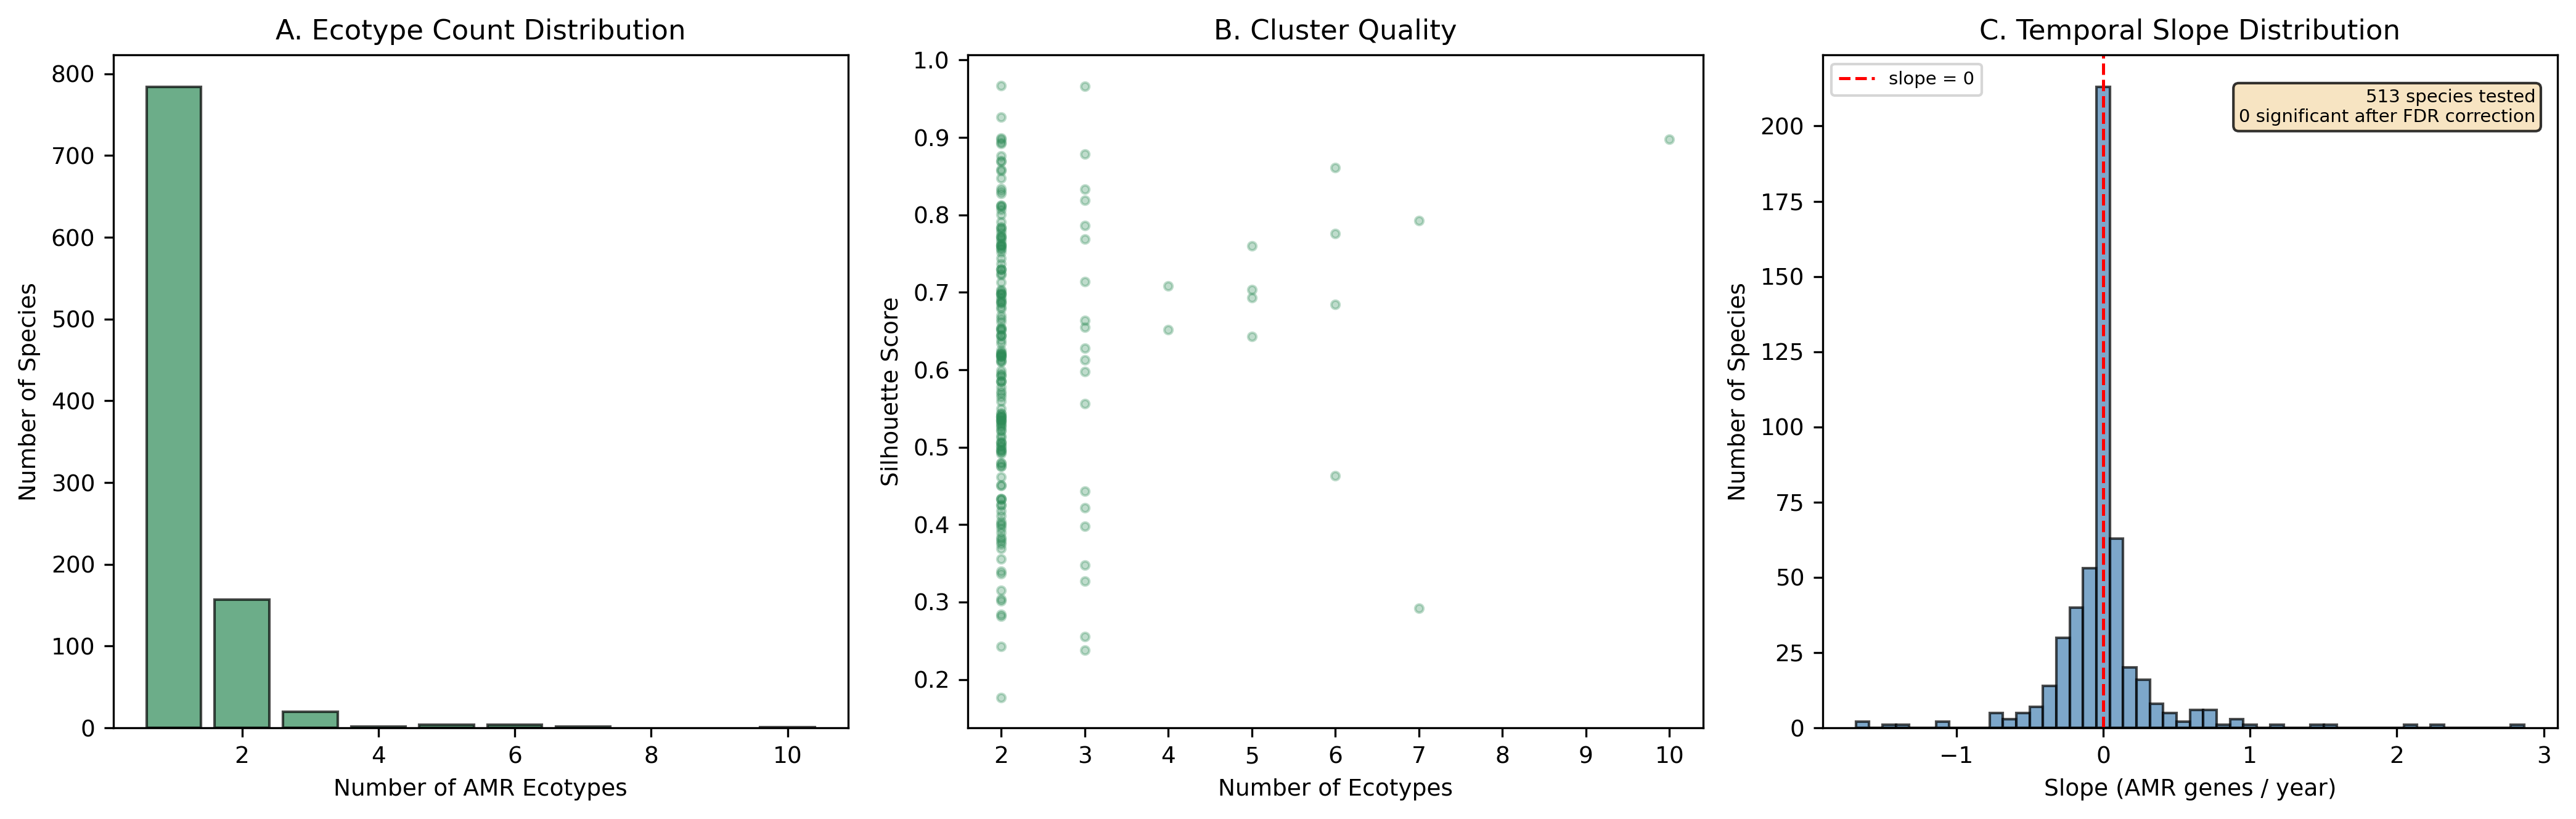

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 4A: Number of ecotypes distribution
ax = axes[0]
if len(ecotypes) > 0:
    ec_counts = ecotypes['n_clusters'].value_counts().sort_index()
    ax.bar(ec_counts.index, ec_counts.values, edgecolor='black', alpha=0.7, color='seagreen')
    ax.set_xlabel('Number of AMR Ecotypes')
    ax.set_ylabel('Number of Species')
    ax.set_title('A. Ecotype Count Distribution')

# 4B: Silhouette vs n_clusters
ax = axes[1]
if len(ecotypes) > 0:
    multi = ecotypes[ecotypes['n_clusters'] >= 2]
    if len(multi) > 0:
        ax.scatter(multi['n_clusters'], multi['silhouette'],
                   alpha=0.3, s=10, c='seagreen')
ax.set_xlabel('Number of Ecotypes')
ax.set_ylabel('Silhouette Score')
ax.set_title('B. Cluster Quality')

# 4C: Slope distribution histogram for ALL species (not just significant)
ax = axes[2]
if len(temporal) > 0:
    ax.hist(temporal['slope'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', ls='--', linewidth=1.2, label='slope = 0')
    n_total = len(temporal)
    n_sig = (temporal['fdr'] < 0.05).sum() if 'fdr' in temporal.columns else 0
    ax.annotate(f'{n_total} species tested\n{n_sig} significant after FDR correction',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.8))
    ax.legend(fontsize=7)
ax.set_xlabel('Slope (AMR genes / year)')
ax.set_ylabel('Number of Species')
ax.set_title('C. Temporal Slope Distribution')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_ecotypes_temporal.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig4_ecotypes_temporal.pdf', bbox_inches='tight')
plt.show()

## 7. Key Statistics for Abstract

In [8]:
print("="*70)
print("KEY STATISTICS FOR ABSTRACT")
print("="*70)

n_species = len(summary)
total_genomes = summary['n_genomes'].sum()
total_amr = summary['n_amr'].sum()

print(f"\nScale:")
print(f"  {n_species} species, {total_genomes:,} genomes, {total_amr:,} AMR gene-species pairs")

print(f"\nVariation (NB02):")
print(f"  Median variability index: {summary['variability_index'].median():.3f}")
print(f"  Median Jaccard diversity: {summary['mean_jaccard'].median():.3f}")
print(f"  Fixed/Variable/Rare: {prevalence['prevalence_class'].value_counts().to_dict()}")

if len(islands) > 0:
    print(f"\nResistance Islands (NB03):")
    print(f"  {len(islands)} islands in {islands['gtdb_species_clade_id'].nunique()} species")
    print(f"  Mean size: {islands['size'].mean():.1f} genes, mean phi: {islands['mean_phi'].mean():.2f}")

if len(mantel) > 0:
    print(f"\nPhylogenetic Signal (NB04):")
    sig_m = (mantel.get('mantel_fdr_all', pd.Series(dtype=float)) < 0.05).sum()
    print(f"  {sig_m}/{len(mantel)} species with significant signal")
    print(f"  Median Mantel r: {mantel['mantel_r_all'].median():.3f}")
    if 'mantel_r_core' in mantel.columns:
        print(f"  Core vs non-core: {mantel['mantel_r_core'].median():.3f} vs {mantel['mantel_r_noncore'].median():.3f}")

if len(ecotypes) > 0:
    print(f"\nEcotypes (NB05):")
    print(f"  {(ecotypes['n_clusters'] >= 2).sum()}/{len(ecotypes)} species with >= 2 ecotypes")

if len(temporal) > 0:
    sig_t = temporal[temporal.get('fdr', pd.Series(dtype=float)) < 0.05]
    print(f"\nTemporal (NB06):")
    print(f"  {len(sig_t)} species with significant trend")
    if len(sig_t) > 0:
        print(f"  Increasing: {(sig_t['slope'] > 0).sum()}, Decreasing: {(sig_t['slope'] < 0).sum()}")

print(f"\n" + "="*70)

KEY STATISTICS FOR ABSTRACT

Scale:
  1305 species, 180,025 genomes, 37,444 AMR gene-species pairs

Variation (NB02):
  Median variability index: 0.526
  Median Jaccard diversity: 0.435
  Fixed/Variable/Rare: {'rare': 19198, 'variable': 15454, 'fixed': 2792}

Resistance Islands (NB03):
  1517 islands in 705 species
  Mean size: 6.2 genes, mean phi: 0.83

Phylogenetic Signal (NB04):
  701/1261 species with significant signal
  Median Mantel r: 0.247
  Core vs non-core: 0.117 vs 0.222

Ecotypes (NB05):
  190/974 species with >= 2 ecotypes

Temporal (NB06):
  0 species with significant trend

